<a href="https://colab.research.google.com/github/Alamsyah-WM/Classification-DBP-Binding-vs-Non-Binding/blob/Finale/Ensemble_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {DEVICE}")

def set_seed(seed=42):
    """Set random seed untuk reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")

set_seed(42)

🖥️  Using device: cpu
✅ Random seed set to 42


In [2]:
class BindingPredictor1280(nn.Module):
    """Model untuk ESM1b (1280-dim) dengan BatchNorm"""
    def __init__(self, input_dim=1280):
        super().__init__()
        self.network = nn.Sequential(
            # Layer 1: 1280 → 512
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2: 512 → 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3: 256 → 128
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 4: 128 → 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output: 64 → 2
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)


class BindingPredictor320(nn.Module):
    """Model untuk ESM2 (320-dim) tanpa BatchNorm"""
    def __init__(self, input_dim=320):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1: 320 → 256
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2: 256 → 128
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output: 128 → 2
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)


In [3]:
def load_model_1280(model_path, device):
    """Load model ESM1b (1280-dim)"""
    model = BindingPredictor1280(input_dim=1280).to(device)
    checkpoint = torch.load(model_path, map_location=device)

    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.eval()
    print(f"✅ Model 1280 loaded: 1280→512→256→128→64→2")
    return model


def load_model_320(model_path, device):
    """Load model ESM2 (320-dim)"""
    model = BindingPredictor320(input_dim=320).to(device)
    checkpoint = torch.load(model_path, map_location=device)

    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.eval()
    print(f"✅ Model 320 loaded: 320→256→128→2")
    return model

# Load models
print("\n📦 Loading Models...")
MODEL_1280_PATH = "/content/drive/MyDrive/esm1b_embed/mlp_esm1b_pdb_best.pth"
MODEL_320_PATH = "/content/drive/MyDrive/esm2_embed/esm2_embeds_PDB/mlp_esm2_pdb_classifier.pt"

model_1280 = load_model_1280(MODEL_1280_PATH, DEVICE)
model_320 = load_model_320(MODEL_320_PATH, DEVICE)




📦 Loading Models...
✅ Model 1280 loaded: 1280→512→256→128→64→2
✅ Model 320 loaded: 320→256→128→2


In [8]:
print("="*60)
print("LOADING TRAINING DATA & CREATING VALIDATION SPLIT")
print("="*60)

# Load TRAINING embeddings (bukan test)
TRAIN_EMB_1280 = "/content/drive/MyDrive/esm1b_embed/DL/PDB/x_PDB_train.pt"
TRAIN_EMB_320 = "/content/drive/MyDrive/esm2_embed/esm2_embeds_PDB/X_PDB_train.pt"
TRAIN_LABELS = "/content/drive/MyDrive/esm1b_embed/DL/PDB/y_PDB_train.npy"

# Load embeddings ESM1b (1280-dim)
if TRAIN_EMB_1280.endswith('.pt'):
    emb1280_train = torch.load(TRAIN_EMB_1280)
    if isinstance(emb1280_train, torch.Tensor):
        emb1280_train = emb1280_train.cpu().numpy()
    print(f"Loaded ESM1b train embeddings: {emb1280_train.shape}")

# Load embeddings ESM2 (320-dim)
if TRAIN_EMB_320.endswith('.pt'):
    emb320_train = torch.load(TRAIN_EMB_320)
    if isinstance(emb320_train, torch.Tensor):
        emb320_train = emb320_train.cpu().numpy()
    print(f"Loaded ESM2 train embeddings: {emb320_train.shape}")

# Load labels
labels_train = np.load(TRAIN_LABELS)
print(f"Loaded labels: {labels_train.shape}")

# Split training menjadi train + validation (80:20 atau sesuai kebutuhan)
X1280_train, X1280_val, X320_train, X320_val, y_train, y_val = train_test_split(
    emb1280_train,
    emb320_train,
    labels_train,
    test_size=0.2,  # 20% untuk validation
    random_state=42,
    stratify=labels_train  # Stratified split
)

print(f"\n{'='*60}")
print("SPLIT RESULTS:")
print(f"{'='*60}")
print(f"ESM1b Train: {X1280_train.shape}, Val: {X1280_val.shape}")
print(f"ESM2 Train: {X320_train.shape}, Val: {X320_val.shape}")
print(f"Labels Train: {y_train.shape}, Val: {y_val.shape}")

# Create validation dataloaders
print(f"\nCreating Validation DataLoaders...")

# Convert to tensors and create datasets
val_dataset_1280 = TensorDataset(
    torch.FloatTensor(X1280_val),
    torch.LongTensor(y_val)
)
val_dataset_320 = TensorDataset(
    torch.FloatTensor(X320_val),
    torch.LongTensor(y_val)
)

# Create dataloaders
valloader1280 = DataLoader(val_dataset_1280, batch_size=32, shuffle=False)
valloader320 = DataLoader(val_dataset_320, batch_size=32, shuffle=False)

print(f"Validation DataLoader 1280: {len(val_dataset_1280)} samples")
print(f"Validation DataLoader 320: {len(val_dataset_320)} samples")

LOADING TRAINING DATA & CREATING VALIDATION SPLIT
Loaded ESM1b train embeddings: (985, 1280)
Loaded ESM2 train embeddings: (985, 320)
Loaded labels: (985,)

SPLIT RESULTS:
ESM1b Train: (788, 1280), Val: (197, 1280)
ESM2 Train: (788, 320), Val: (197, 320)
Labels Train: (788,), Val: (197,)

Creating Validation DataLoaders...
Validation DataLoader 1280: 197 samples
Validation DataLoader 320: 197 samples


In [4]:
def create_dataloader(embedding_path, label_path, batch_size=32):
    """Create DataLoader dengan support .npy, .npz, dan .pt"""

    # Load Embeddings
    if embedding_path.endswith('.pt'):
        embeddings = torch.load(embedding_path)
        if isinstance(embeddings, torch.Tensor):
            embeddings = embeddings.cpu().numpy()
        print(f"   📂 {embedding_path.split('/')[-1]} (PyTorch)")
    elif embedding_path.endswith('.npz'):
        data = np.load(embedding_path)
        keys = list(data.keys())
        embeddings = data[keys[0]]
        print(f"   📂 {embedding_path.split('/')[-1]} (npz, key: {keys[0]})")
    else:
        embeddings = np.load(embedding_path)
        print(f"   📂 {embedding_path.split('/')[-1]} (numpy)")

    # Load Labels
    if label_path.endswith('.pt'):
        labels = torch.load(label_path)
        if isinstance(labels, torch.Tensor):
            labels = labels.cpu().numpy()
        print(f"   📂 {label_path.split('/')[-1]} (PyTorch)")
    elif label_path.endswith('.npz'):
        data = np.load(label_path)
        keys = list(data.keys())
        labels = data[keys[0]]
        print(f"   📂 {label_path.split('/')[-1]} (npz, key: {keys[0]})")
    else:
        labels = np.load(label_path)
        print(f"   📂 {label_path.split('/')[-1]} (numpy)")

    # Validate
    print(f"   ✓ Embeddings: {embeddings.shape}")
    print(f"   ✓ Labels: {labels.shape}")
    assert len(embeddings) == len(labels), "❌ Length mismatch!"

    # Convert to tensors
    X = torch.FloatTensor(embeddings)
    y = torch.LongTensor(labels)

    # Create DataLoader
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    print(f"   ✅ DataLoader: {len(dataset)} samples, batch={batch_size}\n")
    return dataloader


print("\n📊 Creating DataLoaders...")
TEST_EMB_1280 = "/content/drive/MyDrive/esm1b_embed/DL/PDB/x_PDB_test.pt"
TEST_EMB_320 = "/content/drive/MyDrive/esm2_embed/esm2_embeds_PDB/X_PDB_test.pt"
TEST_LABELS = "/content/drive/MyDrive/esm1b_embed/DL/PDB/y_PDB_test.npy"

test_loader_1280 = create_dataloader(TEST_EMB_1280, TEST_LABELS, batch_size=32)
test_loader_320 = create_dataloader(TEST_EMB_320, TEST_LABELS, batch_size=32)


📊 Creating DataLoaders...
   📂 x_PDB_test.pt (PyTorch)
   📂 y_PDB_test.npy (numpy)
   ✓ Embeddings: (186, 1280)
   ✓ Labels: (186,)
   ✅ DataLoader: 186 samples, batch=32

   📂 X_PDB_test.pt (PyTorch)
   📂 y_PDB_test.npy (numpy)
   ✓ Embeddings: (186, 320)
   ✓ Labels: (186,)
   ✅ DataLoader: 186 samples, batch=32



In [5]:
@torch.no_grad()
def evaluate_ensemble_multi_input(models, weights, dataloaders, device):
    """
    Ensemble dengan multi-input (different embedding sizes)
    Persis seperti Minggu4_ensemble approach
    """
    if len(models) != len(weights) or len(models) != len(dataloaders):
        raise ValueError("❌ Length mismatch!")

    for model in models:
        model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    total_weight = sum(weights)

    print(f"\n🔄 Ensemble Evaluation...")
    print(f"   Weights: ESM1b={weights[0]:.1f} | ESM2={weights[1]:.1f}")

    # Parallel iteration
    combined_iterator = zip(*dataloaders)

    for batch_inputs in combined_iterator:
        labels = batch_inputs[0][1].to(device)

        logits_list = []

        # Forward pass per model
        for i, (model, w) in enumerate(zip(models, weights)):
            Xi = batch_inputs[i][0].to(device)
            logits = model(Xi)
            logits_list.append(w * logits)

        # Weighted average di level LOGITS
        combined_logits = torch.stack(logits_list).sum(0) / total_weight

        # Softmax setelah averaging
        combined_prob = F.softmax(combined_logits, dim=1)
        preds = torch.argmax(combined_prob, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(combined_prob.cpu().numpy())

    # Calculate metrics
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    acc = accuracy_score(y_true, y_pred)
    precision_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob[:, 1])

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    class_report = classification_report(
        y_true, y_pred,
        target_names=['Non-binding (0)', 'Binding (1)'],
        digits=3,
        zero_division=0
    )

    # Print results
    print(f"\n{'='*50}")
    print(f"📊 Evaluation Results")
    print(f"{'='*50}")
    print(f"Accuracy      : {acc:.3f}")
    print(f"Precision (M) : {precision_m:.3f}")
    print(f"Recall (M)    : {recall_m:.3f}")
    print(f"F1-Macro      : {f1_macro:.3f}")
    print(f"F1-Weighted   : {f1_weighted:.3f}")
    print(f"MCC           : {mcc:.3f}")
    print(f"Specificity   : {specificity:.3f}")
    print(f"ROC-AUC       : {roc_auc:.3f}")
    print(f"\n{class_report}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-binding', 'Binding'],
                yticklabels=['Non-binding', 'Binding'])
    plt.title(f'Confusion Matrix - Ensemble ({weights[0]:.1f}:{weights[1]:.1f})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    metrics = {
        'accuracy': acc,
        'precision_macro': precision_m,
        'recall_macro': recall_m,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mcc': mcc,
        'specificity': specificity,
        'roc_auc': roc_auc
    }

    return metrics, y_pred, y_prob

ENSEMBLE EVALUATION (ESM1b + ESM2) - VALIDATION SET
Weights: ESM1b=0.6 ESM2=0.4

🔄 Ensemble Evaluation...
   Weights: ESM1b=0.6 | ESM2=0.4

📊 Evaluation Results
Accuracy      : 0.858
Precision (M) : 0.856
Recall (M)    : 0.856
F1-Macro      : 0.856
F1-Weighted   : 0.858
MCC           : 0.712
Specificity   : 0.872
ROC-AUC       : 0.948

                 precision    recall  f1-score   support

Non-binding (0)      0.872     0.872     0.872       109
    Binding (1)      0.841     0.841     0.841        88

       accuracy                          0.858       197
      macro avg      0.856     0.856     0.856       197
   weighted avg      0.858     0.858     0.858       197



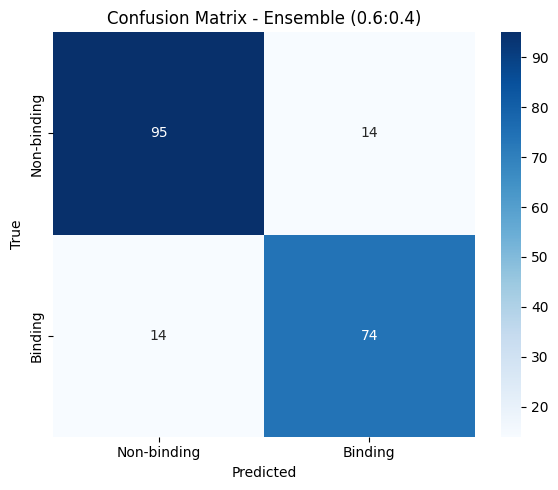

In [12]:
print("="*60)
print("ENSEMBLE EVALUATION (ESM1b + ESM2) - VALIDATION SET")
print("="*60)

weight_configs = [
    [0.6, 0.4],  # ESM1b:ESM2
]

results_summary = []

for weights in weight_configs:
    print("="*60)
    print(f"Weights: ESM1b={weights[0]:.1f} ESM2={weights[1]:.1f}")
    print("="*60)

    metrics, preds, probs = evaluate_ensemble_multi_input(
        models=[model_1280, model_320],
        weights=weights,
        dataloaders=[valloader1280, valloader320],  # ← Validation loaders
        device=DEVICE
    )

    results_summary.append({
        "ESM1b": weights[0],
        "ESM2": weights[1],
        "Acc": metrics["accuracy"],
        "F1": metrics["f1_macro"],
        "MCC": metrics["mcc"],
        "AUC": metrics["roc_auc"]
    })



🎯 ENSEMBLE EVALUATION: ESM1b + ESM2

────────────────────────────────────────────────────────────
⚖️  Weights: ESM1b=0.6 | ESM2=0.4
────────────────────────────────────────────────────────────

🔄 Ensemble Evaluation...
   Weights: ESM1b=0.6 | ESM2=0.4

📊 Evaluation Results
Accuracy      : 0.780
Precision (M) : 0.784
Recall (M)    : 0.780
F1-Macro      : 0.779
F1-Weighted   : 0.779
MCC           : 0.563
Specificity   : 0.839
ROC-AUC       : 0.876

                 precision    recall  f1-score   support

Non-binding (0)      0.750     0.839     0.792        93
    Binding (1)      0.817     0.720     0.766        93

       accuracy                          0.780       186
      macro avg      0.784     0.780     0.779       186
   weighted avg      0.784     0.780     0.779       186



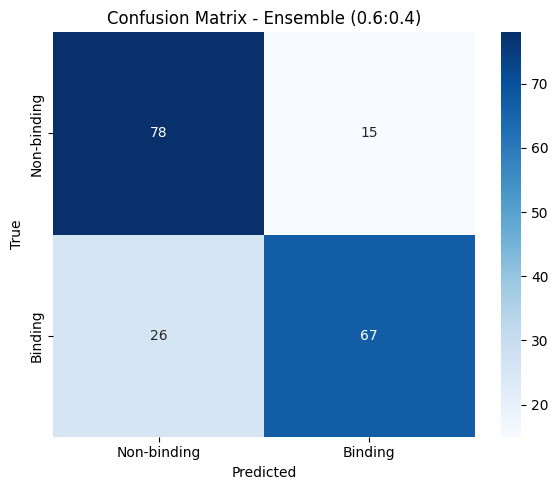

In [6]:
print("\n" + "="*60)
print("🎯 ENSEMBLE EVALUATION: ESM1b + ESM2")
print("="*60)

weight_configs = [
    [0.6, 0.4]
]

results_summary = []

for weights in weight_configs:
    print(f"\n{'─'*60}")
    print(f"⚖️  Weights: ESM1b={weights[0]:.1f} | ESM2={weights[1]:.1f}")
    print(f"{'─'*60}")

    metrics, preds, probs = evaluate_ensemble_multi_input(
        models=[model_1280, model_320],
        weights=weights,
        dataloaders=[test_loader_1280, test_loader_320],
        device=DEVICE
    )

    results_summary.append({
        'ESM1b': weights[0],
        'ESM2': weights[1],
        'Acc': metrics['accuracy'],
        'F1': metrics['f1_macro'],
        'MCC': metrics['mcc'],
        'AUC': metrics['roc_auc']
    })
